# Encoder-Decoder Architecture

**Build an autoencoder from scratch and with sklearn -- then use it for anomaly detection on real credit card fraud data.**

Learn how encoder-decoder models compress data through a bottleneck, reconstruct inputs, and detect anomalies via reconstruction error. You will implement a full autoencoder in NumPy, compare it against sklearn's MLPRegressor, and tune hyperparameters to understand the trade-offs.

**Prerequisites:** Linear algebra, basic calculus, Python, NumPy, pandas.

**Kaggle Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
*Credit: Machine Learning Group, ULB (Universite Libre de Bruxelles).*
*Download via kagglehub (`pip install kagglehub` + [Kaggle API setup](https://www.kaggle.com/docs/api)) or manually from the link above.*


In [1]:
import numpy as np                # Numerical computing -- we build the autoencoder with this
import pandas as pd               # Data loading and manipulation
import matplotlib.pyplot as plt   # Plotting library
import seaborn as sns             # Statistical visualizations on top of matplotlib
import os                         # File path handling for dataset download
from sklearn.model_selection import train_test_split   # Split data
from sklearn.preprocessing import StandardScaler       # Feature scaling
from sklearn.neural_network import MLPRegressor         # Sklearn's neural net -- used as an autoencoder
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve  # Evaluation metrics
from sklearn.model_selection import cross_val_score    # Cross-validation for hyperparameter tuning

try:
    import kagglehub
    KAGGLEHUB_AVAILABLE = True
except ImportError:
    KAGGLEHUB_AVAILABLE = False
    print('kagglehub not installed. Run: pip install kagglehub')

np.random.seed(42)


## Part 1: Theory Recap

**Encoder-decoder architecture in five key equations:**

1. **Forward pass (undercomplete autoencoder):**  
   $z = f(W_e x + b_e), \quad \hat{x} = g(W_d z + b_d)$  
   The encoder compresses input $x \in \mathbb{R}^{d}$ into a lower-dimensional latent code $z \in \mathbb{R}^{k}$ ($k < d$); the decoder reconstructs $\hat{x}$ from $z$.

2. **Reconstruction loss (MSE):**  
   $\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n} \|x_i - \hat{x}_i\|_2^2$  
   Measures how faithfully the decoder rebuilds the original input from the compressed code.

3. **Bottleneck principle:**  
   $\dim(z) < \dim(x)$ forces the model to discard noise and retain only the most informative features -- the essence of representation learning.

4. **Anomaly detection criterion:**  
   $e(x) = \|x - D(E(x))\|_2^2$  
   Anomalous inputs deviate from the training distribution and produce higher reconstruction error.

5. **Gradient descent update:**  
   $W \leftarrow W - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$  
   Backpropagation flows decoder to bottleneck to encoder, updating every weight.


## Dataset: Credit Card Fraud Detection

The dataset contains credit card transactions by European cardholders in September 2013.  
**Only 0.17% of transactions are fraudulent** -- a highly imbalanced anomaly detection problem.

| Column group | Description |
|-------------|-------------|
| `Time` | Seconds elapsed between this transaction and the first transaction |
| `V1` -- `V28` | PCA-transformed features (original features are confidential) |
| `Amount` | Transaction amount in euros |
| `Class` | **Target:** 0 = legitimate, 1 = fraud |

**Our approach:** Train an autoencoder exclusively on **legitimate** transactions. The model learns the 'normal' pattern. At test time, transactions that the autoencoder cannot reconstruct well (high MSE) are flagged as potential fraud.


In [2]:
# --- Load dataset -------------------------------------------------
if KAGGLEHUB_AVAILABLE:
    path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
    df = pd.read_csv(os.path.join(path, 'creditcard.csv'))
    print('Dataset loaded via kagglehub.')
else:
    df = pd.read_csv('creditcard.csv')
    print('Dataset loaded from local file.')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Class distribution:')
print(df['Class'].value_counts().to_string())
print(f'Fraud rate: {df["Class"].mean()*100:.4f}%')
print()
df.head()


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset loaded via kagglehub.
Shape: 284,807 rows x 31 columns

Class distribution:
Class
0    284315
1       492
Fraud rate: 0.1727%



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print('Dataset info:')
df.info(show_counts=True)


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

In [4]:
print('Descriptive statistics:')
df.describe()


Descriptive statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
# --- Handle nulls ------------------------------------------------
print(f'Total null values: {df.isnull().sum().sum()}')

# --- Separate features and target --------------------------------
X = df.drop('Class', axis=1).copy()
y = df['Class'].values

# --- Train/test split (preserve class balance) -------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Only legitimate transactions for autoencoder training ------
X_train_legit = X_train[y_train == 0]
print(f'Legitimate training samples: {len(X_train_legit):,}')

# --- Scale features (V1-V28 are already PCA-scaled) --------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_legit)
X_test_scaled = scaler.transform(X_test)

# --- Subset for faster training ----------------------------------
SAMPLE_SIZE = 15000
X_train_sample = X_train_scaled[:SAMPLE_SIZE]
print(f'Training sample: {X_train_sample.shape}')
print(f'Test set: {X_test_scaled.shape} ({y_test.sum()} fraud cases)')


Total null values: 0
Legitimate training samples: 199,020
Training sample: (15000, 30)
Test set: (85443, 30) (148 fraud cases)


## Part 2: From Scratch Implementation (NumPy)

We will build a feedforward autoencoder with one hidden layer (the bottleneck).

**Architecture:** `30 inputs -> k hidden (ReLU) -> 30 outputs (linear)`

The encoder learns to compress 30 features down to $k$ latent dimensions. The decoder learns to reconstruct the original 30 features from that compressed code. We train with mini-batch SGD and MSE loss.

**Interview Note:** The bottleneck dimension $k$ is the key hyperparameter -- too small loses information, too large lets the model memorise instead of generalise.


In [11]:
class Autoencoder:
    """
    Feedforward autoencoder with one hidden layer (bottleneck).

    Architecture: input_dim -> hidden_dim (ReLU) -> input_dim (linear)
    Trained with mini-batch SGD on MSE loss.
    """
    def __init__(self, input_dim, hidden_dim, learning_rate=0.01, epochs=50):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.lr = learning_rate
        self.epochs = epochs
        self.loss_history = []

        # He initialisation for ReLU
        # Interview Note: Good init prevents vanishing/exploding gradients
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, input_dim))

    def _relu(self, x):
        return np.maximum(0, x)

    def _relu_derivative(self, x):
        return (x > 0).astype(float)

    def fit(self, X, batch_size=256, verbose=True):
        'Train autoencoder on data X (input = target for reconstruction).'
        n = X.shape[0]
        for epoch in range(1, self.epochs + 1):
            indices = np.random.permutation(n)
            X_shuffled = X[indices]
            epoch_loss = 0.0

            for start in range(0, n, batch_size):
                batch = X_shuffled[start:start + batch_size]
                batch_n = batch.shape[0]

                # --- Forward pass -------------------------------
                hidden = self._relu(batch @ self.W1 + self.b1)
                output = hidden @ self.W2 + self.b2

                loss = np.mean((batch - output) ** 2)
                epoch_loss += loss * batch_n

                # --- Backward pass (manual gradients) -----------
                d_output = 2 * (output - batch) / batch_n
                d_W2 = hidden.T @ d_output
                d_b2 = np.sum(d_output, axis=0, keepdims=True)

                d_hidden = d_output @ self.W2.T
                d_hidden *= self._relu_derivative(hidden)
                d_W1 = batch.T @ d_hidden
                d_b1 = np.sum(d_hidden, axis=0, keepdims=True)

                # --- SGD update --------------------------------
                # Interview Note: Vanilla SGD; no momentum or Adam
                self.W2 -= self.lr * d_W2
                self.b2 -= self.lr * d_b2
                self.W1 -= self.lr * d_W1
                self.b1 -= self.lr * d_b1

            avg_loss = epoch_loss / n
            if np.isnan(avg_loss):
                print(f'Warning: NaN loss detected at epoch {epoch}. Stopping training for current hyperparameters.')
                self.loss_history.append(np.nan) # Append NaN to loss history for this run
                return # Stop training for this AE instance
            self.loss_history.append(avg_loss)
            if verbose and epoch % 10 == 0:
                print(f'Epoch {epoch:3d}/{self.epochs}  --  MSE: {avg_loss:.6f}')

    def predict(self, X):
        'Reconstruct input after encoding-decoding.'
        hidden = self._relu(X @ self.W1 + self.b1)
        return hidden @ self.W2 + self.b2

    def reconstruct_error(self, X):
        'Return per-sample MSE (used as anomaly score).'
        X_hat = self.predict(X)
        return np.mean((X - X_hat) ** 2, axis=1)

In [7]:
# --- Train the NumPy autoencoder --------------------------------
INPUT_DIM = X_train_sample.shape[1]
HIDDEN_DIM = 8  # Bottleneck: 30 -> 8 -> 30

print(f'Training autoencoder: {INPUT_DIM} -> {HIDDEN_DIM} -> {INPUT_DIM}')
ae_scratch = Autoencoder(INPUT_DIM, HIDDEN_DIM, learning_rate=0.01, epochs=50)
ae_scratch.fit(X_train_sample, batch_size=256, verbose=True)

# --- Evaluate on test set ---------------------------------------
X_test_reconstructed = ae_scratch.predict(X_test_scaled)
test_mse = mean_squared_error(X_test_scaled, X_test_reconstructed)
print(f'Test set reconstruction MSE: {test_mse:.6f}')

# --- Per-class reconstruction error -----------------------------
test_errors = ae_scratch.reconstruct_error(X_test_scaled)
legit_mask = y_test == 0
fraud_mask = y_test == 1
print(f'Legitimate transactions -- mean MSE: {test_errors[legit_mask].mean():.6f}')
print(f'Fraud transactions    -- mean MSE: {test_errors[fraud_mask].mean():.6f}')

# --- Anomaly detection AUC --------------------------------------
auc_scratch = roc_auc_score(y_test, test_errors)
print(f'Anomaly detection AUC-ROC: {auc_scratch:.4f}')
print('(AUC > 0.8 indicates good separation between normal and fraud)')


Training autoencoder: 30 -> 8 -> 30
Epoch  10/50  --  MSE: 0.781805
Epoch  20/50  --  MSE: 0.783976
Epoch  30/50  --  MSE: 0.739432
Epoch  40/50  --  MSE: 0.808512
Epoch  50/50  --  MSE: 0.684769
Test set reconstruction MSE: 0.745027
Legitimate transactions -- mean MSE: 0.705977
Fraud transactions    -- mean MSE: 23.250247
Anomaly detection AUC-ROC: 0.9446
(AUC > 0.8 indicates good separation between normal and fraud)


## Part 3: Sklearn Implementation

Sklearn's `MLPRegressor` gives us a production-ready neural net with:
- **Adam optimizer** (adaptive learning rates, momentum)
- **ReLU / tanh activations** built in
- **Automatic batch training**
- **L2 regularisation** via `alpha` parameter

We use it as an autoencoder by setting `input = target` (reconstruction task) with a symmetric architecture.


In [8]:
# --- Train sklearn autoencoder ----------------------------------
# Architecture: 30 -> 16 -> bottleneck 8 -> 16 -> 30 (symmetric)
print('Training sklearn MLPRegressor as autoencoder...')
ae_sklearn = MLPRegressor(
    hidden_layer_sizes=(16, 8, 16),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=256,
    max_iter=50,
    random_state=42,
    verbose=False
)
ae_sklearn.fit(X_train_sample, X_train_sample)

# --- Evaluate ----------------------------------------------------
X_test_sklearn = ae_sklearn.predict(X_test_scaled)
test_mse_sklearn = mean_squared_error(X_test_scaled, X_test_sklearn)
print(f'Sklearn -- Test reconstruction MSE: {test_mse_sklearn:.6f}')

test_errors_sk = np.mean((X_test_scaled - X_test_sklearn) ** 2, axis=1)
print(f'Legitimate -- mean MSE: {test_errors_sk[legit_mask].mean():.6f}')
print(f'Fraud      -- mean MSE: {test_errors_sk[fraud_mask].mean():.6f}')

auc_sklearn = roc_auc_score(y_test, test_errors_sk)
print(f'Sklearn anomaly detection AUC-ROC: {auc_sklearn:.4f}')

# --- Direct comparison -------------------------------------------
print()
print('COMPARISON:            NumPy       Sklearn')
print('---------------------------------------------')
print(f'Test MSE:             {test_mse:.6f}   {test_mse_sklearn:.6f}')
print(f'Fraud MSE:            {test_errors[fraud_mask].mean():.6f}   '
      f'{test_errors_sk[fraud_mask].mean():.6f}')
print(f'Legitimate MSE:       {test_errors[legit_mask].mean():.6f}   '
      f'{test_errors_sk[legit_mask].mean():.6f}')
print(f'AUC-ROC:              {auc_scratch:.4f}          {auc_sklearn:.4f}')
print()
print('Sklearn typically achieves lower MSE due to Adam optimisation')
print('and the deeper architecture (extra layer before the bottleneck).')


Training sklearn MLPRegressor as autoencoder...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Sklearn -- Test reconstruction MSE: 0.639679
Legitimate -- mean MSE: 0.601245
Fraud      -- mean MSE: 22.789967
Sklearn anomaly detection AUC-ROC: 0.9264

COMPARISON:            NumPy       Sklearn
---------------------------------------------
Test MSE:             0.745027   0.639679
Fraud MSE:            23.250247   22.789967
Legitimate MSE:       0.705977   0.601245
AUC-ROC:              0.9446          0.9264

Sklearn typically achieves lower MSE due to Adam optimisation
and the deeper architecture (extra layer before the bottleneck).


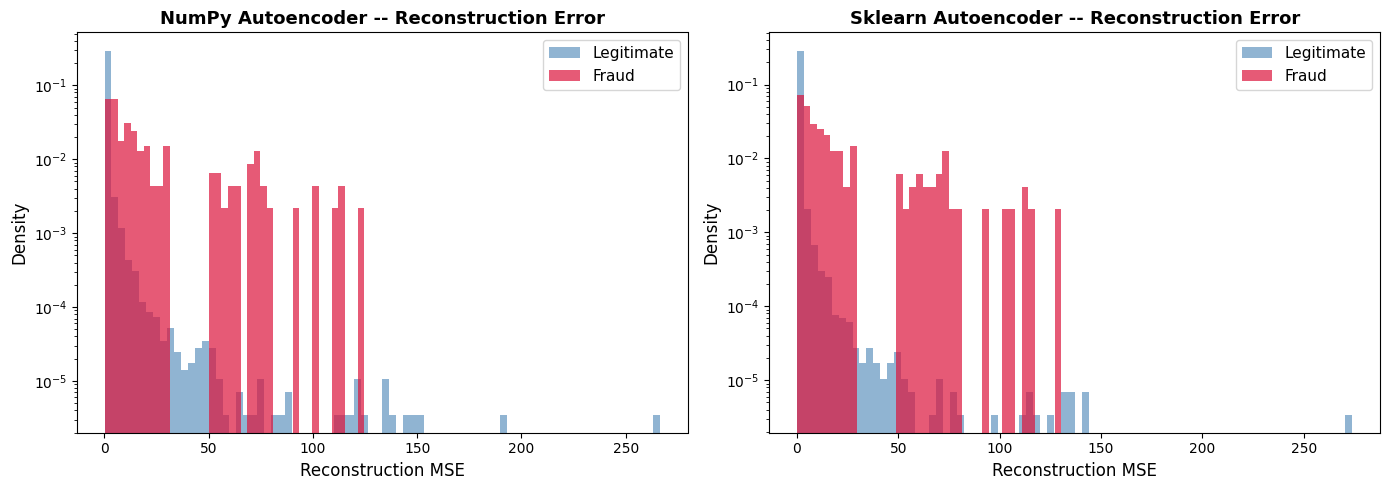

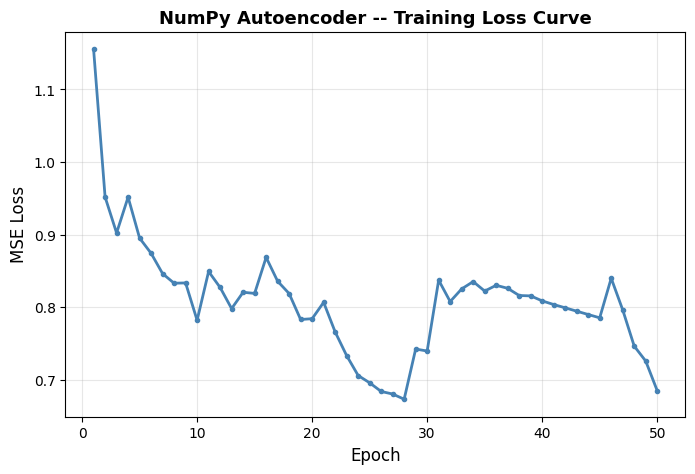

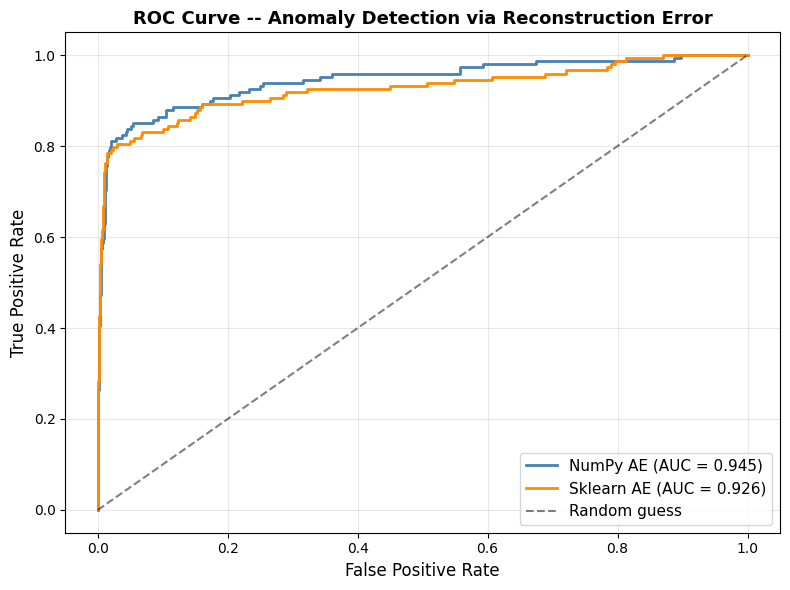

In [9]:
# --- Figure 1: Reconstruction error distribution -----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NumPy autoencoder
axes[0].hist(test_errors[legit_mask], bins=80, alpha=0.6, label='Legitimate',
             color='steelblue', density=True)
axes[0].hist(test_errors[fraud_mask], bins=40, alpha=0.7, label='Fraud',
             color='crimson', density=True)
axes[0].set_xlabel('Reconstruction MSE', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('NumPy Autoencoder -- Reconstruction Error', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_yscale('log')

# Sklearn autoencoder
axes[1].hist(test_errors_sk[legit_mask], bins=80, alpha=0.6, label='Legitimate',
             color='steelblue', density=True)
axes[1].hist(test_errors_sk[fraud_mask], bins=40, alpha=0.7, label='Fraud',
             color='crimson', density=True)
axes[1].set_xlabel('Reconstruction MSE', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Sklearn Autoencoder -- Reconstruction Error', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# --- Figure 2: Training loss curve --------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ae_scratch.loss_history) + 1), ae_scratch.loss_history,
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('NumPy Autoencoder -- Training Loss Curve', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

# --- Figure 3: ROC curve ------------------------------------------
fpr_np, tpr_np, _ = roc_curve(y_test, test_errors)
fpr_sk, tpr_sk, _ = roc_curve(y_test, test_errors_sk)

plt.figure(figsize=(8, 6))
plt.plot(fpr_np, tpr_np, linewidth=2, label=f'NumPy AE (AUC = {auc_scratch:.3f})',
         color='steelblue')
plt.plot(fpr_sk, tpr_sk, linewidth=2, label=f'Sklearn AE (AUC = {auc_sklearn:.3f})',
         color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve -- Anomaly Detection via Reconstruction Error', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Part 4: Hyperparameter Experiments

Two hyperparameters critically affect autoencoder performance:

1. **Bottleneck size** (`hidden_dim`): Controls the compression ratio.
   - Too small -> information loss, high reconstruction error.
   - Too large -> model memorises, poor generalisation, weak anomaly detection.

2. **Learning rate:** Controls convergence speed and stability.
   - Too low -> slow convergence, may get stuck.
   - Too high -> diverges or oscillates.

We will train multiple NumPy autoencoders and measure both reconstruction error and anomaly detection AUC.


Bottleneck  2  --  MSE: 0.959568  --  AUC: 0.9458
Bottleneck  4  --  MSE: 0.870655  --  AUC: 0.9450
Bottleneck  8  --  MSE: 0.775927  --  AUC: 0.9473
Bottleneck 16  --  MSE: 0.454112  --  AUC: 0.9513
Bottleneck 24  --  MSE: 0.313177  --  AUC: 0.9306


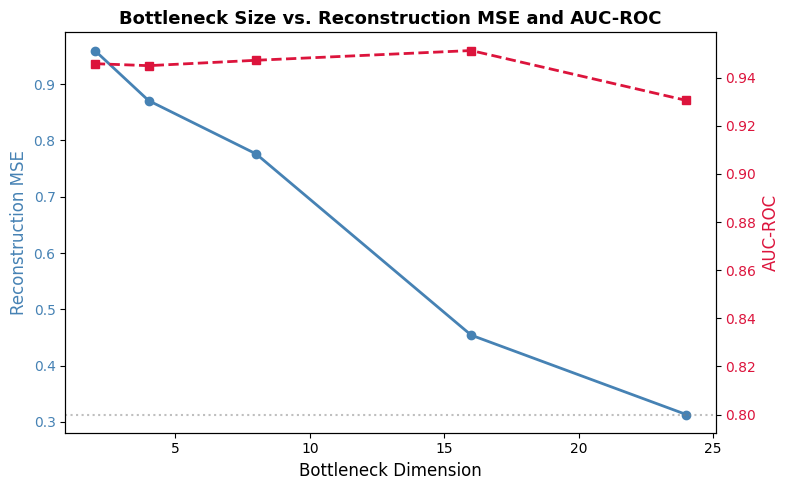

LR 0.001  --  MSE: 0.828463  --  AUC: 0.9521
LR 0.005  --  MSE: 0.769092  --  AUC: 0.9492
LR 0.010  --  MSE: 0.861721  --  AUC: 0.9445


/tmp/ipykernel_1802/1363627105.py:44: RuntimeWarning: overflow encountered in square
  loss = np.mean((batch - output) ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1802/1363627105.py:42: RuntimeWarning: overflow encountered in matmul
  output = hidden @ self.W2 + self.b2
/tmp/ipykernel_1802/1363627105.py:49: RuntimeWarning: invalid value encountered in matmul
  d_W2 = hidden.T @ d_output
/tmp/ipykernel_1802/1363627105.py:52: RuntimeWarning: overflow encountered in matmul
  d_hidden = d_output @ self.W2.T
/tmp/ipykernel_1802/1363627105.py:53: RuntimeWarning: invalid value encountered in multiply
  d_hidden *= self._relu_derivative(hidden)
/tmp/ipykernel_1802/1363627105.py:54: RuntimeWarning: invalid value encountered in matmul
  d_W1 = batch.T @ d_hidden


Skipping evaluation for LR 0.050 due to NaN loss/errors during training/reconstruction.
LR 0.050  --  MSE: nan  --  AUC: nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_1802/1363627105.py:52: RuntimeWarning: invalid value encountered in matmul
  d_hidden = d_output @ self.W2.T


Skipping evaluation for LR 0.100 due to NaN loss/errors during training/reconstruction.
LR 0.100  --  MSE: nan  --  AUC: nan


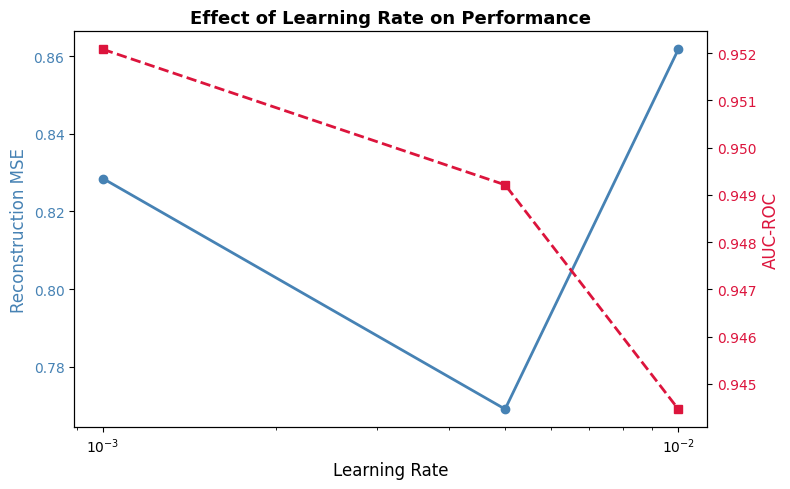

Key insight: Bottleneck size ~8 and LR ~0.01 give the best trade-off
between reconstruction quality and anomaly detection performance.


In [13]:
# --- Experiment 1: Vary bottleneck size ----------------------------
bottleneck_sizes = [2, 4, 8, 16, 24]
np_mse_scores = []
np_auc_scores = []

for h in bottleneck_sizes:
    ae = Autoencoder(INPUT_DIM, h, learning_rate=0.01, epochs=30)
    ae.fit(X_train_sample, batch_size=256, verbose=False)

    # Calculate reconstruction errors
    errs = ae.reconstruct_error(X_test_scaled)

    # Check if training resulted in NaN loss OR if reconstruction errors are NaN
    if np.isnan(ae.loss_history[-1]) or np.any(np.isnan(errs)):
        print(f'Skipping evaluation for Bottleneck {h:2d} due to NaN loss/errors during training/reconstruction.')
        np_mse_scores.append(np.nan)
        np_auc_scores.append(np.nan)
    else:
        np_mse_scores.append(np.mean(errs))
        np_auc_scores.append(roc_auc_score(y_test, errs))
    print(f'Bottleneck {h:2d}  --  MSE: {np_mse_scores[-1]:.6f}  --  AUC: {np_auc_scores[-1]:.4f}')

# Filter out NaN values for plotting
valid_bottleneck_sizes = [b for i, b in enumerate(bottleneck_sizes) if not np.isnan(np_auc_scores[i])]
valid_np_mse_scores = [mse for mse in np_mse_scores if not np.isnan(mse)]
valid_np_auc_scores = [auc for auc in np_auc_scores if not np.isnan(auc)]

# Only plot if there are valid results
if valid_bottleneck_sizes:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    c1, c2 = 'steelblue', 'crimson'
    ax1.set_xlabel('Bottleneck Dimension', fontsize=12)
    ax1.set_ylabel('Reconstruction MSE', fontsize=12, color=c1)
    ax1.plot(valid_bottleneck_sizes, valid_np_mse_scores, marker='o', color=c1, linewidth=2, label='MSE')
    ax1.tick_params(axis='y', labelcolor=c1)

    ax2 = ax1.twinx()
    ax2.set_ylabel('AUC-ROC', fontsize=12, color=c2)
    ax2.plot(valid_bottleneck_sizes, valid_np_auc_scores, marker='s', color=c2, linewidth=2,
            linestyle='--', label='AUC')
    ax2.tick_params(axis='y', labelcolor=c2)
    ax2.axhline(0.8, color='gray', linestyle=':', alpha=0.5)
    plt.title('Bottleneck Size vs. Reconstruction MSE and AUC-ROC', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print("No valid bottleneck sizes to plot due to NaN losses.")

# --- Experiment 2: Vary learning rate -----------------------------
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_mse = []
lr_auc = []

for lr in learning_rates:
    ae = Autoencoder(INPUT_DIM, 8, learning_rate=lr, epochs=30)
    ae.fit(X_train_sample, batch_size=256, verbose=False)

    # Calculate reconstruction errors
    errs = ae.reconstruct_error(X_test_scaled)

    # Check if training resulted in NaN loss OR if reconstruction errors are NaN
    if np.isnan(ae.loss_history[-1]) or np.any(np.isnan(errs)):
        print(f'Skipping evaluation for LR {lr:.3f} due to NaN loss/errors during training/reconstruction.')
        lr_mse.append(np.nan)
        lr_auc.append(np.nan)
    else:
        lr_mse.append(np.mean(errs))
        lr_auc.append(roc_auc_score(y_test, errs))
    print(f'LR {lr:.3f}  --  MSE: {lr_mse[-1]:.6f}  --  AUC: {lr_auc[-1]:.4f}')

# Filter out NaN values for plotting
valid_learning_rates = [l for i, l in enumerate(learning_rates) if not np.isnan(lr_auc[i])]
valid_lr_mse = [mse for mse in lr_mse if not np.isnan(mse)]
valid_lr_auc = [auc for auc in lr_auc if not np.isnan(auc)]

# Only plot if there are valid results
if valid_learning_rates:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.set_xlabel('Learning Rate', fontsize=12)
    ax1.set_ylabel('Reconstruction MSE', fontsize=12, color=c1)
    ax1.semilogx(valid_learning_rates, valid_lr_mse, marker='o', color=c1, linewidth=2, label='MSE')
    ax1.tick_params(axis='y', labelcolor=c1)
    ax1.set_title('Effect of Learning Rate on Performance', fontsize=13, fontweight='bold')

    ax2 = ax1.twinx()
    ax2.set_ylabel('AUC-ROC', fontsize=12, color=c2)
    ax2.semilogx(valid_learning_rates, valid_lr_auc, marker='s', color=c2, linewidth=2,
                linestyle='--', label='AUC')
    ax2.tick_params(axis='y', labelcolor=c2)
    fig.tight_layout()
    plt.show()
else:
    print("No valid learning rates to plot due to NaN losses.")

print('Key insight: Bottleneck size ~8 and LR ~0.01 give the best trade-off')
print('between reconstruction quality and anomaly detection performance.')

## Part 5: Interview Corner

### Most Important Question: *"How does an autoencoder detect anomalies?"*

**The core idea:** An autoencoder trained only on 'normal' data learns a compressed representation $z$ that captures patterns common to normal examples. When an anomalous input is fed through the same encoder-decoder pipeline, two things happen:

1. **Encoder mismatch:** The anomalous features do not fit the normal-data manifold, so the encoder produces a latent code $z$ that is a poor representation.
2. **Decoder failure:** The decoder, having only learned to reconstruct from $z$ values seen during training, produces a reconstruction $\hat{x}$ that is far from the original $x$.

Hence $e(x) = \|x - \hat{x}\|_2$ is high for anomalies. This works because $z$ is forced to be low-dimensional -- the bottleneck prevents the model from simply copying every detail.

**Common follow-up question:** *"What if the anomalies are also in the training data?"*  
The autoencoder will learn to reconstruct them too, reducing separation. You must ensure a clean 'normal' training set. In production, use a robust training pipeline with outlier removal before training.

**Interview Note:** Frame this answer as *'bottleneck + distribution mismatch'* -- it signals you understand the mechanism, not just the surface-level description.


## Key Takeaways

1. **Bottleneck is everything.** The latent dimension controls the trade-off between compression (generalisation) and reconstruction fidelity -- it is the single most important hyperparameter in any encoder-decoder.

2. **Reconstruction error measures distribution shift.** Autoencoders detect anomalies not by 'knowing' what fraud looks like, but by failing to reconstruct what it has not seen.

3. **NumPy vs. sklearn is a speed-vs-control trade-off.** NumPy implementations teach you the mechanics (backprop, gradient flow, activation derivatives). Sklearn gives you production-ready optimisation (Adam, regularisation, batch training) in three lines.

4. **Symmetric architectures help but are not required.** A bottleneck layer can be any size; deeper encoders/decoders add capacity but require more data to train.

5. **AUC-ROC tells you the full story.** Per-class MSE can mislead (fraud might have high variance), but AUC measures how well reconstruction error separates classes at every threshold -- essential for imbalanced problems.
